# ZOMATO DATA ANALYSIS PROJECT

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv("Zomato data.csv")
df.head()
 

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


DATA CLEANING AND PREPROCESSING

conver the data type of column rate 

In [3]:

def handleRate(value):
    value = str(value).split('/')
    value=value[0]; # 4.1 /5 value[0] 
    return float(value)

df['rate']=df['rate'].apply(handleRate)

In [4]:
df.head(4)
# rate 4.1/5 convert split /

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet


COLUMNS

In [5]:
df.columns.to_list()

['name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'approx_cost(for two people)',
 'listed_in(type)']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


MISSING VALUES 

In [7]:
df.isna().sum().sum()

0

TYPE OF RESTURANT

In [8]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


- ques - type of restuarent

univariate analysis


Text(0.5, 0, 'Type of restaurent')

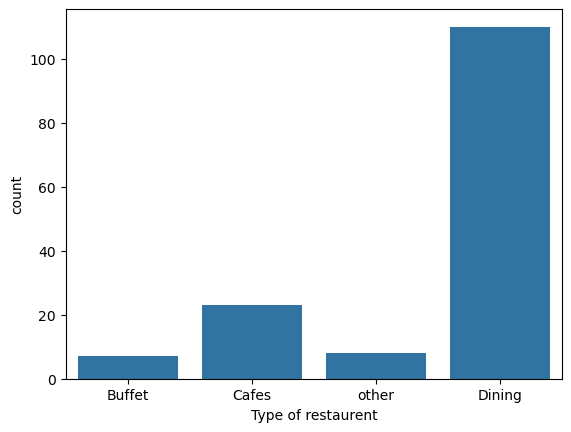

In [9]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Type of restaurent')

majority of the restuarent falls in dinning cateogry


In [10]:
# 2- votes of each type ( line plot )
# - type of restuarent and votes highest votes 

grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes':grouped_data})
grouped_data
result



,votes
listed_in(type),
Buffet,3028
Cafes,6434
Dining,20363
other,9367


Text(0, 0.5, 'Votes')

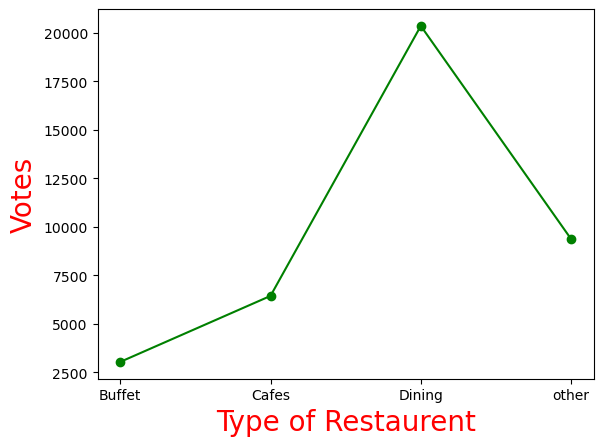

In [11]:
plt.plot(result,c='green',marker='o')
plt.xlabel('Type of Restaurent',c='red',size=20)
plt.ylabel('Votes',c='red',size=20)

conclusion - dining restaurent has recieved has maximum votes

Text(0.5, 1.0, 'rating distribution')

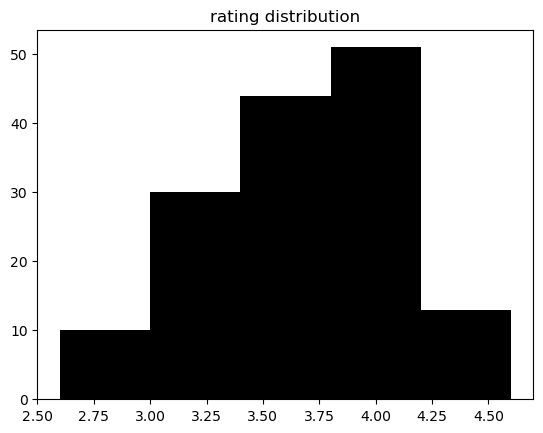

In [ ]:
# 3-- what are the majority of restuarents have recieved highest rating 
plt.hist(df['rate'],bins=5,color='black')
plt.title('rating distribution')


-- The majority restaurent recieved ratings from 3.5 to 4

In [ ]:
# AVERAGE order spending by couples 
df.head() 

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

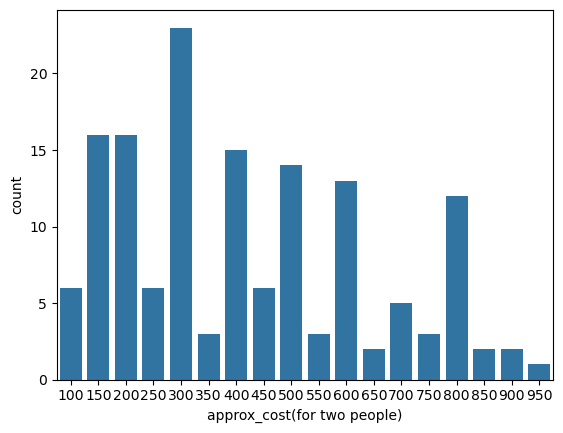

In [17]:
cuple_data = df['approx_cost(for two people)']
sns.countplot(x=cuple_data)

conclusion - the majority of couples prefer restuarents with an approximmate cost for 300

<Axes: xlabel='online_order', ylabel='rate'>

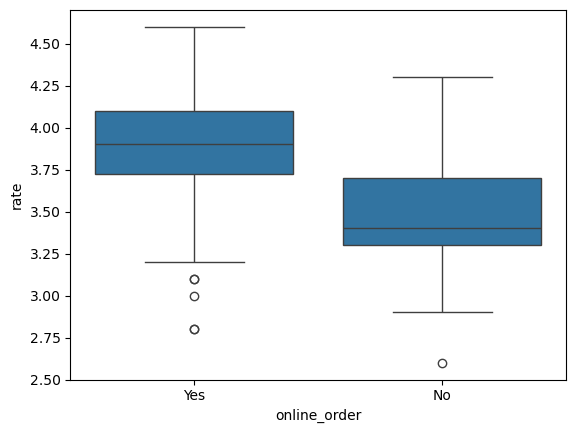

In [21]:
# Online mode recieved maxiumum rating 
df.head()
sns.boxplot(x='online_order',y='rate',data=df)

Conclusion -- offline order recieved lower rating in comparison to offline

In [ ]:
pivot_table = df.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size',fill_value=0)
pivot_table


online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


<Axes: xlabel='online_order', ylabel='listed_in(type)'>

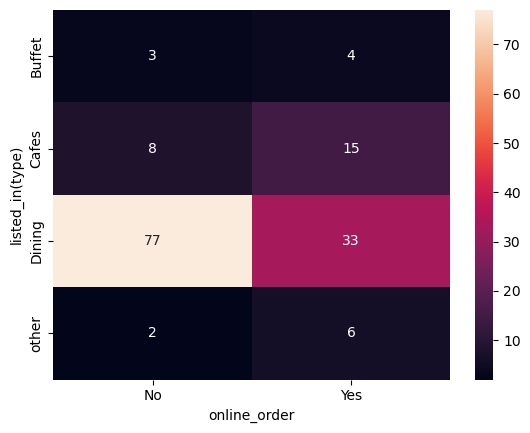

In [26]:
sns.heatmap(pivot_table,annot=True,fmt='d')

conclusion - Dining restaurents primarily accept offline orders , whereas cafes primarilt recieve online orders . This suggest that clients prefer order in person at restaurents , but prefer online ordering at cafes .